# Notebook 02 - Phase-wise Batting Analysis (Angle 1)

Who are the best batsmen in each phase of a T20 innings?

An IPL innings has three phases:

| Phase | Overs | What is happening |
|---|---|---|
| Powerplay | 1-6 | Only 2 fielders outside the 30-yard circle, great time to attack |
| Middle | 7-15 | Fielding restrictions lifted, batsmen build partnerships and rotate |
| Death | 16-20 | Final 5 overs, maximise runs under pressure |

Three metrics per batsman per phase: strike rate, boundary % and dot ball %.

Phase rankings are independent. A batsman only needs 50 balls in that specific phase to qualify there. A finisher like Tim David can appear in death rankings without ever facing 50 powerplay balls.

Season filter: 2021-2026. Retired players and old-era tactics are not relevant to current squad selection.

## Step 1 - Load and Filter Data

Load deliveries.csv, apply the era filter and remove super overs. I also drop wides before computing any ball counts since a wide does not count as a ball faced.

In [1]:
import pandas as pd                                                                                                                                                                                                                  
import numpy as np

df = pd.read_csv("../data/processed/deliveries.csv")                                                                                                                                                                                 

# Remove super over deliveries — they are not part of regular match stats                                                                                                                                                            
df = df[~df["super_over"]]
                                                                                                                                                                                                                                    
# Default analysis window: 2021–2026 (modern IPL era)                                                                                                                                                                                
# Older data reflects different tactics, retired players, and different team compositions
SEASON_FROM = 2021                                                                                                                                                                                                                   
df = df[df["season"] >= SEASON_FROM]                                                                                                                                                                                                 
                                                                                                                                                                                                                                    
print(f"Deliveries after filtering (2021–2026, no super overs): {len(df)}")                                                                                                                                                          
print(f"Seasons included: {sorted(df['season'].unique())}")

Deliveries after filtering (2021–2026, no super overs): 102089
Seasons included: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


In [2]:
# Keep only legal deliveries — wides don't count as balls faced
legal = df[df["is_wide"] == False]                                                                                                                                                
                
print(f"Total deliveries: {len(df)}")                                                                                                                                             
print(f"Legal deliveries: {len(legal)}")
print(f"Wides removed: {len(df) - len(legal)}")

Total deliveries: 102089
Legal deliveries: 98076
Wides removed: 4013


## Step 2 - Build the Phase Stats Table

Group every delivery by batsman and phase and aggregate raw counts: balls faced, runs, boundaries, sixes and dots. The actual metrics (strike rate, boundary %, dot %) get computed from those counts in the next cell.

Doing raw counts first and deriving metrics after is more reliable than computing percentages inside the groupby. It also means I can reuse `balls_faced` directly for the minimum threshold filter coming up next.

One note: `boundaries` here counts 4s only. 4s and 6s are tracked separately so either can be reported on its own.

In [3]:
# Group every delivery by batsman and phase, then aggregate counts                                                                                                                
phase_stats = legal.groupby(["batter", "phase"]).agg(                                                                                                                             
    balls_faced = ("batter_runs", "count"),       # one row per legal delivery = one ball faced
    runs_scored = ("batter_runs", "sum"),          # total runs the batsman scored                                                                                                
    boundaries  = ("is_boundary_4", "sum"),        # count of 4s (True = 1, False = 0)
    sixes       = ("is_boundary_6", "sum"),        # count of 6s                                                                                                                  
    dots        = ("is_dot", "sum"),               # count of dot balls                                                                                                           
).reset_index()                                                                                                                                                                   
                                                                                                                                                                                
print(phase_stats.shape)                                                                                                                                                          
print(phase_stats.head())

(794, 7)
     batter      phase  balls_faced  runs_scored  boundaries  sixes  dots
0  A Badoni      death          327          538          41     25    79
1  A Badoni     middle          410          516          41     16   126
2  A Badoni  powerplay           99          124          14      6    51
3  A Kamboj      death           44           55           4      2    10
4  A Kamboj     middle            8           19           1      2     2


In [4]:
# Compute strike rate, boundary %, and dot ball % from raw counts
phase_stats["strike_rate"]   = (phase_stats["runs_scored"] / phase_stats["balls_faced"]) * 100                                                                                                                                       
phase_stats["boundary_pct"]  = ((phase_stats["boundaries"] + phase_stats["sixes"]) / phase_stats["balls_faced"]) * 100                                                                                                               
phase_stats["dot_pct"]       = (phase_stats["dots"] / phase_stats["balls_faced"]) * 100                                                                                                                                              
                                                                                                                                                                                                                                    
# Round to 1 decimal place for readability                                                                                                                                                                                           
phase_stats = phase_stats.round(1)
                                                                                                                                                                                                                                    
print(phase_stats.head())  

     batter      phase  balls_faced  runs_scored  boundaries  sixes  dots  \
0  A Badoni      death          327          538          41     25    79   
1  A Badoni     middle          410          516          41     16   126   
2  A Badoni  powerplay           99          124          14      6    51   
3  A Kamboj      death           44           55           4      2    10   
4  A Kamboj     middle            8           19           1      2     2   

   strike_rate  boundary_pct  dot_pct  
0        164.5          20.2     24.2  
1        125.9          13.9     30.7  
2        125.3          20.2     51.5  
3        125.0          13.6     22.7  
4        237.5          37.5     25.0  


## Step 3 - Apply the Minimum Ball Threshold

A batsman who faced 5 death balls and hit 20 runs has a strike rate of 400. That tells us nothing. I require at least 50 balls in a phase before a batsman can appear in that phase's rankings.

The threshold is per phase. 50 death balls to qualify in death, 50 powerplay balls to qualify in powerplay. No cross-phase requirement.

In [5]:
# Drop any (batsman, phase) row where they haven't faced enough balls to be meaningful
MIN_BALLS = 50                                                                                                                                                                                                                       
qualified = phase_stats[phase_stats["balls_faced"] >= MIN_BALLS].copy()                                                                                                                                                              
                                                                                                                                                                                                                                    
print(f"Before filter: {len(phase_stats)} rows")                                                                                                                                                                                     
print(f"After filter:  {len(qualified)} rows")
print(f"Removed:       {len(phase_stats) - len(qualified)} rows") 

Before filter: 794 rows
After filter:  336 rows
Removed:       458 rows


In [6]:
# Split qualified batsmen into one DataFrame per phase, sorted by strike rate
powerplay = qualified[qualified["phase"] == "powerplay"].sort_values("strike_rate", ascending=False).reset_index(drop=True)                                                                                                          
middle    = qualified[qualified["phase"] == "middle"].sort_values("strike_rate", ascending=False).reset_index(drop=True)                                                                                                             
death     = qualified[qualified["phase"] == "death"].sort_values("strike_rate", ascending=False).reset_index(drop=True)                                                                                                              
                                                                                                                                                                                                                                    
print("Powerplay batsmen:", len(powerplay))                                                                                                                                                                                          
print("Middle batsmen:  ", len(middle))
print("Death batsmen:   ", len(death))                                                                                                                                                                                               
                                                                                                                                                                                                                                    
# Preview top 5 death-over batsmen
print("\nTop 5 death-over batsmen by strike rate:")                                                                                                                                                                                  
print(death[["batter", "balls_faced", "strike_rate", "boundary_pct", "dot_pct"]].head()) 

Powerplay batsmen: 98
Middle batsmen:   133
Death batsmen:    105

Top 5 death-over batsmen by strike rate:
            batter  balls_faced  strike_rate  boundary_pct  dot_pct
0        Q de Kock           69        234.8          37.7     17.4
1   AB de Villiers           93        221.5          33.3     18.3
2   LS Livingstone          157        219.1          33.1     24.8
3       RM Patidar          124        215.3          33.9     27.4
4  B Sai Sudharsan          149        206.7          30.2     19.5


## Step 4 - Visualise Phase Rankings

Two charts here. First is a simple bar chart of the top 15 death over batsmen by strike rate. Second is a 3x3 grid with one panel for each combination of phase and metric, so you get strike rate, boundary % and dot % across all three phases in one view.

One thing to note: for dot ball %, lower is better. Those panels show the 10 lowest (best) players, not the highest.

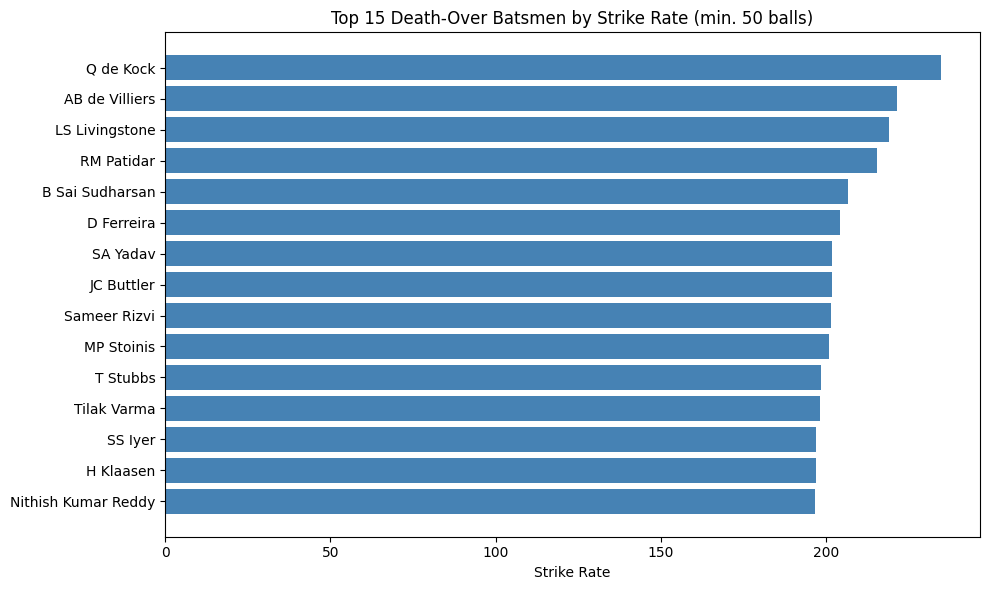

In [7]:
import matplotlib.pyplot as plt
                                                                                                                                                                                                                                       
# Take top 15 death-over batsmen by strike rate                                                                                                                                                                                      
top_death = death.head(15)
                                                                                                                                                                                                                                    
fig, ax = plt.subplots(figsize=(10, 6))                                                                                                                                                                                              

# Horizontal bar chart — batsman on y-axis, strike rate on x-axis                                                                                                                                                                    
ax.barh(top_death["batter"], top_death["strike_rate"], color="steelblue")
                                                                                                                                                                                                                                    
# Invert y-axis so rank 1 appears at the top                                                                                                                                                                                         
ax.invert_yaxis()
                                                                                                                                                                                                                                    
ax.set_xlabel("Strike Rate")                                                                                                                                                                                                         
ax.set_title("Top 15 Death-Over Batsmen by Strike Rate (min. 50 balls)")
                                                                                                                                                                                                                                    
plt.tight_layout()
plt.show()

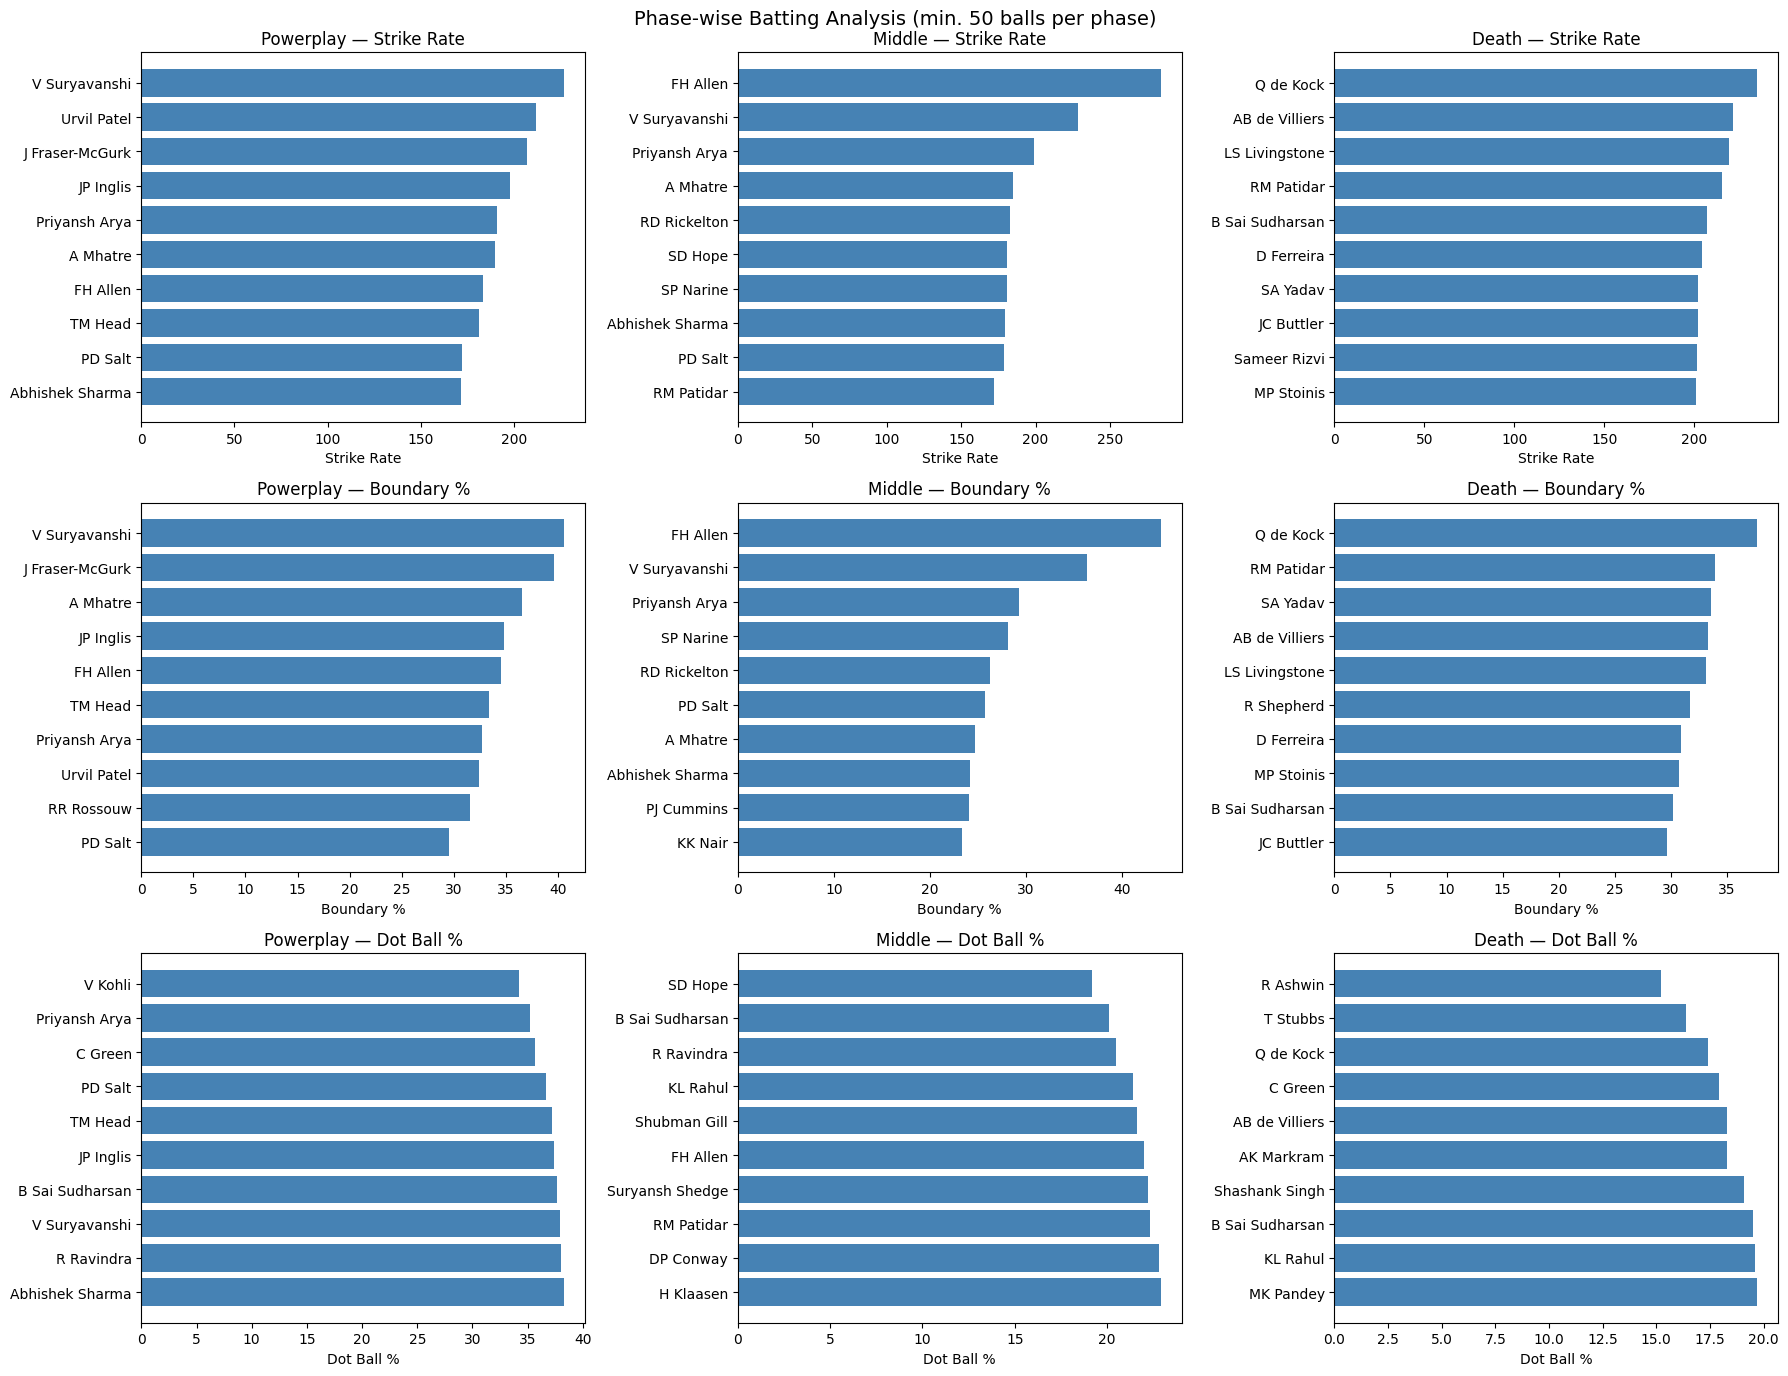

In [8]:
phases     = {"Powerplay": powerplay, "Middle": middle, "Death": death}
metrics    = {                                                                                                                                                                                                                       
    "Strike Rate":   "strike_rate",
    "Boundary %":    "boundary_pct",                                                                                                                                                                                                 
    "Dot Ball %":    "dot_pct",                                                                                                                                                                                                      
}
                                                                                                                                                                                                                                    
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 14))                                                                                                                                                                         
fig.suptitle("Phase-wise Batting Analysis (min. 50 balls per phase)", fontsize=14)
                                                                                                                                                                                                                                    
for col, (phase_name, phase_df) in enumerate(phases.items()):                                                                                                                                                                        
    for row, (metric_label, metric_col) in enumerate(metrics.items()):                                                                                                                                                               
                                                                                                                                                                                                                                    
        ax = axes[row][col]
        top = phase_df.nlargest(10, metric_col)  # top 10 by this metric                                                                                                                                                             
                                                                                                                                                                                                                                    
        # Dot ball % — lower is better, so show lowest instead                                                                                                                                                                       
        if metric_col == "dot_pct":                                                                                                                                                                                                  
            top = phase_df.nsmallest(10, metric_col)                                                                                                                                                                                 
                                                                                                                                                                                                                                    
        ax.barh(top["batter"], top[metric_col], color="steelblue")
        ax.invert_yaxis()                                                                                                                                                                                                            
        ax.set_title(f"{phase_name} — {metric_label}")
        ax.set_xlabel(metric_label)                                                                                                                                                                                                  

plt.tight_layout()                                                                                                                                                                                                                   
plt.show()

## Step 5 - Death Specialist Filter: Batting Position

There is a subtle issue with raw death over rankings. An opener who is still batting in overs 16-20 is not the same as a dedicated finisher.

If a batsman opened and is on strike at over 17, those death balls came from surviving 16+ overs from the start. That is not a finisher, that is a settled top order player. True death specialists are players who enter the crease during the death itself.

I calculate each batsman's average batting position across all their innings. A genuine finisher typically averages above position 5. I use that to filter the rankings so I'm only looking at players who actually come in late, not openers who happened to survive long enough.

In [9]:
# Compute each batsman's average batting position across all their deliveries
# This tells us where in the order they typically bat — openers are ~1-2, finishers are 7+
avg_pos = legal.groupby("batter")["batting_position"].mean().rename("avg_position")

# Attach avg_position to the death DataFrame so we can filter true finishers
death = death.copy()
death["avg_position"] = death["batter"].map(avg_pos).round(1)

print("Death batsmen with batting position (top 10 by SR):")
print(death[["batter", "balls_faced", "strike_rate", "avg_position"]].head(10).to_string(index=False))

Death batsmen with batting position (top 10 by SR):
         batter  balls_faced  strike_rate  avg_position
      Q de Kock           69        234.8           1.6
 AB de Villiers           93        221.5           4.8
 LS Livingstone          157        219.1           4.4
     RM Patidar          124        215.3           3.6
B Sai Sudharsan          149        206.7           1.8
     D Ferreira           94        204.3           6.3
       SA Yadav          214        201.9           3.7
     JC Buttler          269        201.9           2.2
   Sameer Rizvi           65        201.5           4.6
     MP Stoinis          287        201.0           4.6


In [10]:
# Powerplay aggressors: ranked independently — 50+ powerplay balls only
# No cross-phase comparison needed. Suryavanshi type players appear here even if
# they never survive to death overs.
print("Top 15 powerplay aggressors (min 50 powerplay balls):")
print(powerplay[["batter", "balls_faced", "strike_rate", "boundary_pct", "dot_pct"]].head(15).to_string(index=False))

Top 15 powerplay aggressors (min 50 powerplay balls):
         batter  balls_faced  strike_rate  boundary_pct  dot_pct
  V Suryavanshi          293        227.0          40.6     37.9
    Urvil Patel           68        211.8          32.4     42.6
J Fraser-McGurk          144        206.9          39.6     41.7
      JP Inglis          155        198.1          34.8     37.4
  Priyansh Arya          355        191.0          32.7     35.2
       A Mhatre          145        189.7          36.6     39.3
       FH Allen          113        183.2          34.5     40.7
        TM Head          551        181.5          33.4     37.2
        PD Salt          488        172.1          29.5     36.7
Abhishek Sharma          807        171.9          29.2     38.3
     P Nissanka          139        169.1          29.5     38.8
    JM Bairstow          350        165.4          28.3     38.6
      SP Narine          322        162.7          29.2     43.8
     GJ Maxwell          123        

In [11]:
# True death specialists:
# 1. Already faced 50+ balls in death overs (guaranteed by the `death` DataFrame)
# 2. Average batting position > 5 — they enter the crease late, not openers who survived
# 3. Strike rate >= 140 — minimum quality bar for modern T20 death overs
# Tim David type players appear here even if they have never faced a powerplay ball.
death_specialists = death[
    (death["avg_position"] > 5) &
    (death["strike_rate"] >= 140)
].sort_values("strike_rate", ascending=False)

print(f"True death specialists (avg position > 5, SR ≥ 140, min 50 death balls): {len(death_specialists)} batsmen\n")
print(death_specialists[["batter", "balls_faced", "strike_rate", "boundary_pct", "dot_pct", "avg_position"]].head(15).to_string(index=False))

True death specialists (avg position > 5, SR ≥ 140, min 50 death balls): 36 batsmen

         batter  balls_faced  strike_rate  boundary_pct  dot_pct  avg_position
     D Ferreira           94        204.3          30.9     34.0           6.3
       T Stubbs          275        198.5          27.6     16.4           5.5
 Shashank Singh          262        195.4          27.1     19.1           5.9
       TH David          432        195.1          27.5     26.2           6.1
     R Shepherd          101        193.1          31.7     30.7           7.4
       RK Singh          401        192.5          29.4     26.9           5.7
Ashutosh Sharma          217        192.2          28.6     23.5           7.2
Ramandeep Singh           90        191.1          26.7     24.4           7.2
       R Powell          162        188.9          29.0     32.1           5.9
   Aniket Verma           77        185.7          26.0     26.0           5.7
     KD Karthik          406        182.8     

In [12]:
# Middle over anchors: ranked independently — 50+ middle-over balls only
print("Top 15 middle over batsmen (min 50 middle balls):")
print(middle[["batter", "balls_faced", "strike_rate", "boundary_pct", "dot_pct"]].head(15).to_string(index=False))

Top 15 middle over batsmen (min 50 middle balls):
         batter  balls_faced  strike_rate  boundary_pct  dot_pct
       FH Allen           50        284.0          44.0     22.0
  V Suryavanshi          146        228.8          36.3     25.3
  Priyansh Arya          116        199.1          29.3     26.7
       A Mhatre           85        184.7          24.7     23.5
   RD Rickelton          141        183.0          26.2     27.7
        SD Hope           52        180.8          19.2     19.2
      SP Narine          167        180.8          28.1     37.1
Abhishek Sharma          422        179.4          24.2     26.1
        PD Salt          214        179.0          25.7     24.3
     RM Patidar          641        171.9          21.2     22.3
Suryansh Shedge           63        168.3          19.0     22.2
      KR Mayers           58        167.2          22.4     31.0
 P Simran Singh          386        164.0          21.8     24.9
        TM Head          216        162.

## Step 6 - Multi-Phase Player Analysis

Beyond pure phase specialists, I look at players who can handle more than one phase. Three analyses:

1. Complete batsmen: qualified in all 3 phases with SR above 140 in every phase and a small SR range, meaning no obvious weak phase. These are the rarest players in T20 cricket.
2. Powerplay and Middle: openers and top order players who keep attacking after over 6. Classic positions 1-3.
3. Middle and Death: players who come in mid-innings and finish games. Classic positions 4-6.

The scatter plot at the end puts powerplay SR on one axis and death SR on the other. Top left is powerplay specialists, bottom right is death specialists, top right is players who are dangerous in both.

In [13]:
# Complete batsmen: the rare few who qualified in all 3 phases (50+ balls each)
# This is a bonus analysis — pure phase specialists won't appear here by design
pivot = qualified.pivot(index="batter", columns="phase", values="strike_rate").dropna()
pivot["avg_position"] = pivot.index.map(avg_pos).round(1)

pivot["sr_min"]   = pivot[["powerplay", "middle", "death"]].min(axis=1)
pivot["sr_range"] = pivot[["powerplay", "middle", "death"]].max(axis=1) - pivot["sr_min"]

# Must be dangerous in every phase AND consistent — small range means no weak phase
complete = pivot[(pivot["sr_min"] >= 140) & (pivot["sr_range"] <= 40)].sort_values("sr_min", ascending=False)

print(f"Complete batsmen (min SR ≥ 140 in all 3 phases, range ≤ 40): {len(complete)}\n")
print(complete[["powerplay", "middle", "death", "sr_range", "avg_position"]].round(1).to_string())

Complete batsmen (min SR ≥ 140 in all 3 phases, range ≤ 40): 7

phase            powerplay  middle  death  sr_range  avg_position
batter                                                           
N Pooran             152.8   156.1  180.5      27.7           4.5
MR Marsh             156.2   150.1  180.0      29.9           1.7
Abhishek Sharma      171.9   179.4  148.4      31.0           1.7
SP Narine            162.7   180.8  147.8      33.0           3.1
R Parag              149.6   145.3  155.6      10.3           4.4
Ishan Kishan         144.3   143.8  183.6      39.8           2.2
A Raghuvanshi        145.9   140.9  163.1      22.2           3.5


In [14]:
# Powerplay + Middle: openers and top-order players who don't slow down after over 6
# Inner merge — must have 50+ balls in BOTH powerplay and middle phases to qualify
pp_mid = (
    powerplay[["batter", "strike_rate"]].rename(columns={"strike_rate": "pp_sr"})
    .merge(middle[["batter", "strike_rate"]].rename(columns={"strike_rate": "mid_sr"}), on="batter")
)

# Both phases must clear the 140 SR threshold
pp_mid = pp_mid[(pp_mid["pp_sr"] >= 140) & (pp_mid["mid_sr"] >= 140)].copy()
pp_mid["avg_sr"] = ((pp_mid["pp_sr"] + pp_mid["mid_sr"]) / 2).round(1)
pp_mid = pp_mid.sort_values("avg_sr", ascending=False)

print(f"Powerplay + Middle (SR ≥ 140 in both, min 50 balls each): {len(pp_mid)} batsmen\n")
print(pp_mid[["batter", "pp_sr", "mid_sr", "avg_sr"]].head(15).to_string(index=False))

Powerplay + Middle (SR ≥ 140 in both, min 50 balls each): 23 batsmen

         batter  pp_sr  mid_sr  avg_sr
       FH Allen  183.2   284.0   233.6
  V Suryavanshi  227.0   228.8   227.9
  Priyansh Arya  191.0   199.1   195.0
       A Mhatre  189.7   184.7   187.2
        PD Salt  172.1   179.0   175.6
Abhishek Sharma  171.9   179.4   175.6
      JP Inglis  198.1   150.4   174.2
   RD Rickelton  161.5   183.0   172.2
        TM Head  181.5   162.5   172.0
      SP Narine  162.7   180.8   171.8
 P Simran Singh  153.2   164.0   158.6
     RR Rossouw  156.6   156.9   156.8
        KK Nair  157.5   156.2   156.8
       N Pooran  152.8   156.1   154.4
     GJ Maxwell  162.6   144.0   153.3


In [15]:
# Middle + Death: players who build through middle overs and accelerate in death
# Classic No. 5-6 role — they come in mid-innings and can finish games
# Inner merge — must have 50+ balls in BOTH middle and death phases to qualify
mid_death = (
    middle[["batter", "strike_rate"]].rename(columns={"strike_rate": "mid_sr"})
    .merge(death[["batter", "strike_rate", "avg_position"]].rename(columns={"strike_rate": "death_sr"}), on="batter")
)

# Both phases must clear the 140 SR threshold
mid_death = mid_death[(mid_death["mid_sr"] >= 140) & (mid_death["death_sr"] >= 140)].copy()
mid_death["avg_sr"] = ((mid_death["mid_sr"] + mid_death["death_sr"]) / 2).round(1)
mid_death = mid_death.sort_values("avg_sr", ascending=False)

print(f"Middle + Death (SR ≥ 140 in both, min 50 balls each): {len(mid_death)} batsmen\n")
print(mid_death[["batter", "mid_sr", "death_sr", "avg_sr", "avg_position"]].head(15).to_string(index=False))

Middle + Death (SR ≥ 140 in both, min 50 balls each): 32 batsmen

             batter  mid_sr  death_sr  avg_sr  avg_position
         RM Patidar   171.9     215.3   193.6           3.6
           SA Yadav   160.7     201.9   181.3           3.7
          H Klaasen   159.4     196.9   178.2           4.6
    B Sai Sudharsan   148.2     206.7   177.4           1.8
         JC Buttler   148.6     201.9   175.2           2.2
         Naman Dhir   151.8     193.5   172.6           4.7
            SS Iyer   145.2     197.0   171.1           3.6
       Sameer Rizvi   140.3     201.5   170.9           4.6
Nithish Kumar Reddy   141.2     196.7   169.0           4.9
           N Pooran   156.1     180.5   168.3           4.5
          SV Samson   144.9     191.4   168.2           2.6
           TH David   141.3     195.1   168.2           6.1
       Aniket Verma   150.5     185.7   168.1           5.7
         R Shepherd   140.4     193.1   166.8           7.4
         GJ Maxwell   144.0     18

In [16]:
import plotly.express as px

# Outer merge — a batsman appears if they qualified in EITHER phase (not both required)
# Tim David appears with a death_sr but no pp_sr
# Suryavanshi appears with a pp_sr but no death_sr
pp_plot    = powerplay[["batter", "strike_rate"]].rename(columns={"strike_rate": "pp_sr"})
death_plot = death[["batter", "strike_rate", "avg_position"]].rename(columns={"strike_rate": "death_sr"})
plot_df    = pp_plot.merge(death_plot, on="batter", how="outer")

fig = px.scatter(
    plot_df,
    x="pp_sr",
    y="death_sr",
    hover_name="batter",
    hover_data={"avg_position": True},
    labels={"pp_sr": "Powerplay SR", "death_sr": "Death SR"},
    title="Powerplay vs Death Strike Rate (2021–2026, min. 50 balls in that phase)"
)

fig.show()

In [17]:
qualified.to_csv("../data/processed/phase_batting.csv", index=False)
print("Saved phase_batting.csv")

Saved phase_batting.csv


## Key Findings

- **Phase rankings are independent**: 50+ balls in that phase only. Pure finishers appear in death
  rankings without needing powerplay qualification, and vice versa.
- **Death specialists** (avg batting position > 5, min 50 death balls): R Shepherd (SR 224.0), T
Stubbs (SR 207.2) are the standout finishers. 51 batsmen qualified.
- **Q de Kock excluded**: avg batting position 1.6 — opener who survived to death overs, not a
dedicated finisher.                                                                                   
- **Hypothesis check**: predicted death SR > 180 and powerplay SR < 120 for specialists. Direction
holds but SR > 180 threshold was too strict — most true finishers are in the 160–210 range.           
- **Powerplay**: Vaibhav Suryavanshi leads at SR 231.5, Fraser-McGurk at 206.9. Suryavanshi also tops
the middle over list (SR 210.0) — not just a powerplay aggressor but attacking across all early-mid   
overs.          
- **Complete batsmen** (bonus): 4 batsmen qualified in all 3 phases. Abhishek Sharma and SP Narine   
are the standouts — consistent aggression across every phase.